In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

# Data Preprocessing

### Training image Preprocessing

In [2]:
#load dataset
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    image_size=(128,128),
    batch_size=32,
    label_mode="categorical",
    shuffle=True
)

validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    image_size=(128,128),
    batch_size=32,
    label_mode="categorical",
    shuffle=False
)

print("Class Names:", training_set.class_names)

Found 7000 files belonging to 2 classes.
Found 3000 files belonging to 2 classes.
Class Names: ['fake', 'real']


In [28]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 2), dtype=tf.float32, name=None))>

In [29]:
validation_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 2), dtype=tf.float32, name=None))>

In [30]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[1.3925e+02 1.4525e+02 1.1725e+02]
   [1.3400e+02 1.4300e+02 1.1400e+02]
   [1.3375e+02 1.4275e+02 1.1375e+02]
   ...
   [1.3950e+02 1.5050e+02 1.1650e+02]
   [1.4150e+02 1.5150e+02 1.1650e+02]
   [1.4350e+02 1.5350e+02 1.1850e+02]]

  [[1.3375e+02 1.4275e+02 1.1375e+02]
   [1.3150e+02 1.4050e+02 1.1150e+02]
   [1.3400e+02 1.4300e+02 1.1200e+02]
   ...
   [1.4100e+02 1.5200e+02 1.1800e+02]
   [1.4025e+02 1.5025e+02 1.1625e+02]
   [1.3725e+02 1.4725e+02 1.1225e+02]]

  [[1.3275e+02 1.4175e+02 1.1275e+02]
   [1.3225e+02 1.4125e+02 1.1025e+02]
   [1.3200e+02 1.4300e+02 1.1100e+02]
   ...
   [1.4050e+02 1.4950e+02 1.1850e+02]
   [1.3925e+02 1.4925e+02 1.1525e+02]
   [1.3750e+02 1.4750e+02 1.1250e+02]]

  ...

  [[2.3600e+02 2.4000e+02 2.4900e+02]
   [2.3500e+02 2.3900e+02 2.4800e+02]
   [2.3475e+02 2.3875e+02 2.4775e+02]
   ...
   [7.5750e+01 1.0725e+02 7.0500e+01]
   [8.2000e+01 1.0975e+02 7.6500e+01]
   [8.7750e+01 1.1275e+02 8.2750e+01]]

  [[2.3350e+02 2.3750e+02 2.4650e+

In [31]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
training_set = training_set.map(lambda x, y: (normalization_layer(x), y))
validation_set = validation_set.map(lambda x, y: (normalization_layer(x), y))


In [32]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

labels = np.concatenate([y.numpy() for x, y in training_set], axis=0)
labels = np.argmax(labels, axis=1)  # one-hot to index

class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: 1.0, 1: 1.0}


# Building Model

In [33]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential


In [34]:
model=Sequential()

In [35]:
## Building convolutional Layer

In [36]:
model.add(Conv2D(filters=32,kernel_size=3,padding="same",activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

c:\Users\Gopal Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(Conv2D(filters=64,kernel_size=3,padding="same",activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [38]:
model.add(Conv2D(filters=128,kernel_size=3,padding="same",activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [39]:
model.add(Conv2D(filters=256,kernel_size=3,padding="same",activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [40]:
model.add(Conv2D(filters=512,kernel_size=3,padding="same",activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [41]:
model.add(Dropout(0.25)) ## To Avoid overfitting

In [42]:
model.add(Flatten())

In [ ]:
model.add(Dense(units=128,activation='relu'))

In [ ]:
model.add(Dropout(0.5))

In [45]:
## output layer
# here 2 different class problem so we are neend to here 2 different outputs
# softmax neuron gives the probability of each class in each neurons
model.add(Dense(units=2,activation='softmax' ))

## Compiling the model

In [46]:
## here we are dicrease the learning rate becase of minimize the loss function
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

model.summary()

In [48]:
# training_history=model.fit(x=training_set,validation_data=validation_set,epochs=15)

training_history = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=20,
    class_weight=class_weights
)



Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 197s 869ms/step - accuracy: 0.5046 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 190s 867ms/step - accuracy: 0.4945 - loss: 0.6935 - val_accuracy: 0.5320 - val_loss: 0.6920
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 182s 830ms/step - accuracy: 0.5474 - loss: 0.6859 - val_accuracy: 0.6177 - val_loss: 0.6465
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 183s 837ms/step - accuracy: 0.6324 - loss: 0.6439 - val_accuracy: 0.6790 - val_loss: 0.5923
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 181s 824ms/step - accuracy: 0.6789 - loss: 0.5994 - val_accuracy: 0.7087 - val_loss: 0.5651
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 193s 876ms/step - accuracy: 0.7296 - loss: 0.5400 - val_accuracy: 0.7490 - val_loss: 0.5209
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 195s 890ms/step - accuracy: 0.7776 - loss: 0.4741 - val_accuracy: 0.7557 - val_loss: 0.5025
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 187s 854ms/step - accuracy: 0.7983 -

### Model evaluation

In [49]:
## Model Evaluation on Training set
train_loss,train_acc=model.evaluate(training_set)

print(train_loss,train_acc)

219/219 ━━━━━━━━━━━━━━━━━━━━ 30s 137ms/step - accuracy: 0.9792 - loss: 0.0545
0.05432765558362007 0.9795714020729065


In [50]:
## Model evaluation on validation set
val_loss,val_acc=model.evaluate(validation_set)

print(val_loss,val_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - accuracy: 0.8210 - loss: 0.7370
0.7277626991271973 0.8223333358764648


### Saving Model

In [51]:
model.save("Trained_model.h5")

In [52]:
model.save("Trained_model.keras")

In [53]:
training_history.history

{'accuracy': [0.5028571486473083,
  0.4959999918937683,
  0.5815714001655579,
  0.6434285640716553,
  0.6980000138282776,
  0.74314284324646,
  0.7871428728103638,
  0.8157142996788025,
  0.847428560256958,
  0.8798571228981018,
  0.9007142782211304,
  0.9281428456306458,
  0.9480000138282776,
  0.9614285826683044,
  0.9734285473823547,
  0.9835714101791382,
  0.980571448802948,
  0.9844285845756531,
  0.9827142953872681,
  0.9875714182853699],
 'loss': [0.6933712959289551,
  0.6931946873664856,
  0.6764671206474304,
  0.632226288318634,
  0.583215594291687,
  0.5210433602333069,
  0.4594353437423706,
  0.40556544065475464,
  0.3443067669868469,
  0.2889629602432251,
  0.235648050904274,
  0.17857186496257782,
  0.13584478199481964,
  0.10152905434370041,
  0.07170828431844711,
  0.046100642532110214,
  0.049853935837745667,
  0.03691498562693596,
  0.04492434859275818,
  0.032951273024082184],
 'val_accuracy': [0.5,
  0.5320000052452087,
  0.6176666617393494,
  0.6790000200271606,
  0

In [54]:
## Recording history in json Formate
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [55]:
training_history.history['accuracy']

[0.5028571486473083,
 0.4959999918937683,
 0.5815714001655579,
 0.6434285640716553,
 0.6980000138282776,
 0.74314284324646,
 0.7871428728103638,
 0.8157142996788025,
 0.847428560256958,
 0.8798571228981018,
 0.9007142782211304,
 0.9281428456306458,
 0.9480000138282776,
 0.9614285826683044,
 0.9734285473823547,
 0.9835714101791382,
 0.980571448802948,
 0.9844285845756531,
 0.9827142953872681,
 0.9875714182853699]

In [56]:
training_history.history['val_accuracy']

[0.5,
 0.5320000052452087,
 0.6176666617393494,
 0.6790000200271606,
 0.7086666822433472,
 0.7490000128746033,
 0.7556666731834412,
 0.7923333048820496,
 0.7923333048820496,
 0.796999990940094,
 0.8083333373069763,
 0.831333339214325,
 0.8396666646003723,
 0.8306666612625122,
 0.8343333601951599,
 0.8370000123977661,
 0.8410000205039978,
 0.8349999785423279,
 0.840666651725769,
 0.8223333358764648]

### Accurary Visualization

In [59]:
epochs=[i for i in range(1,21)]
epochs

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

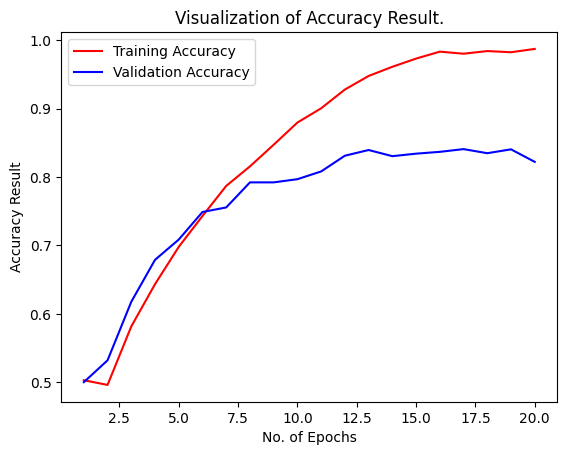

In [62]:
plt.plot(epochs,training_history.history['accuracy'],color='Red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result.")
plt.legend()
plt.show()

### Some other metrics for model evaluation

In [75]:
# class_name=validation_set.class_names
# class_name

In [76]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 3000 files belonging to 2 classes.


In [77]:
y_pred = model.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

3000/3000 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step


In [78]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [79]:
Y_true

<tf.Tensor: shape=(3000,), dtype=int64, numpy=array([0, 0, 0, ..., 1, 1, 1], dtype=int64)>

In [80]:
predicted_categories

<tf.Tensor: shape=(3000,), dtype=int64, numpy=array([0, 0, 0, ..., 1, 1, 1], dtype=int64)>

In [81]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

In [82]:
# # Precision Recall Fscore
# print(classification_report(Y_true,predicted_categories,target_names=class_name))

### Confusion matrix visualization

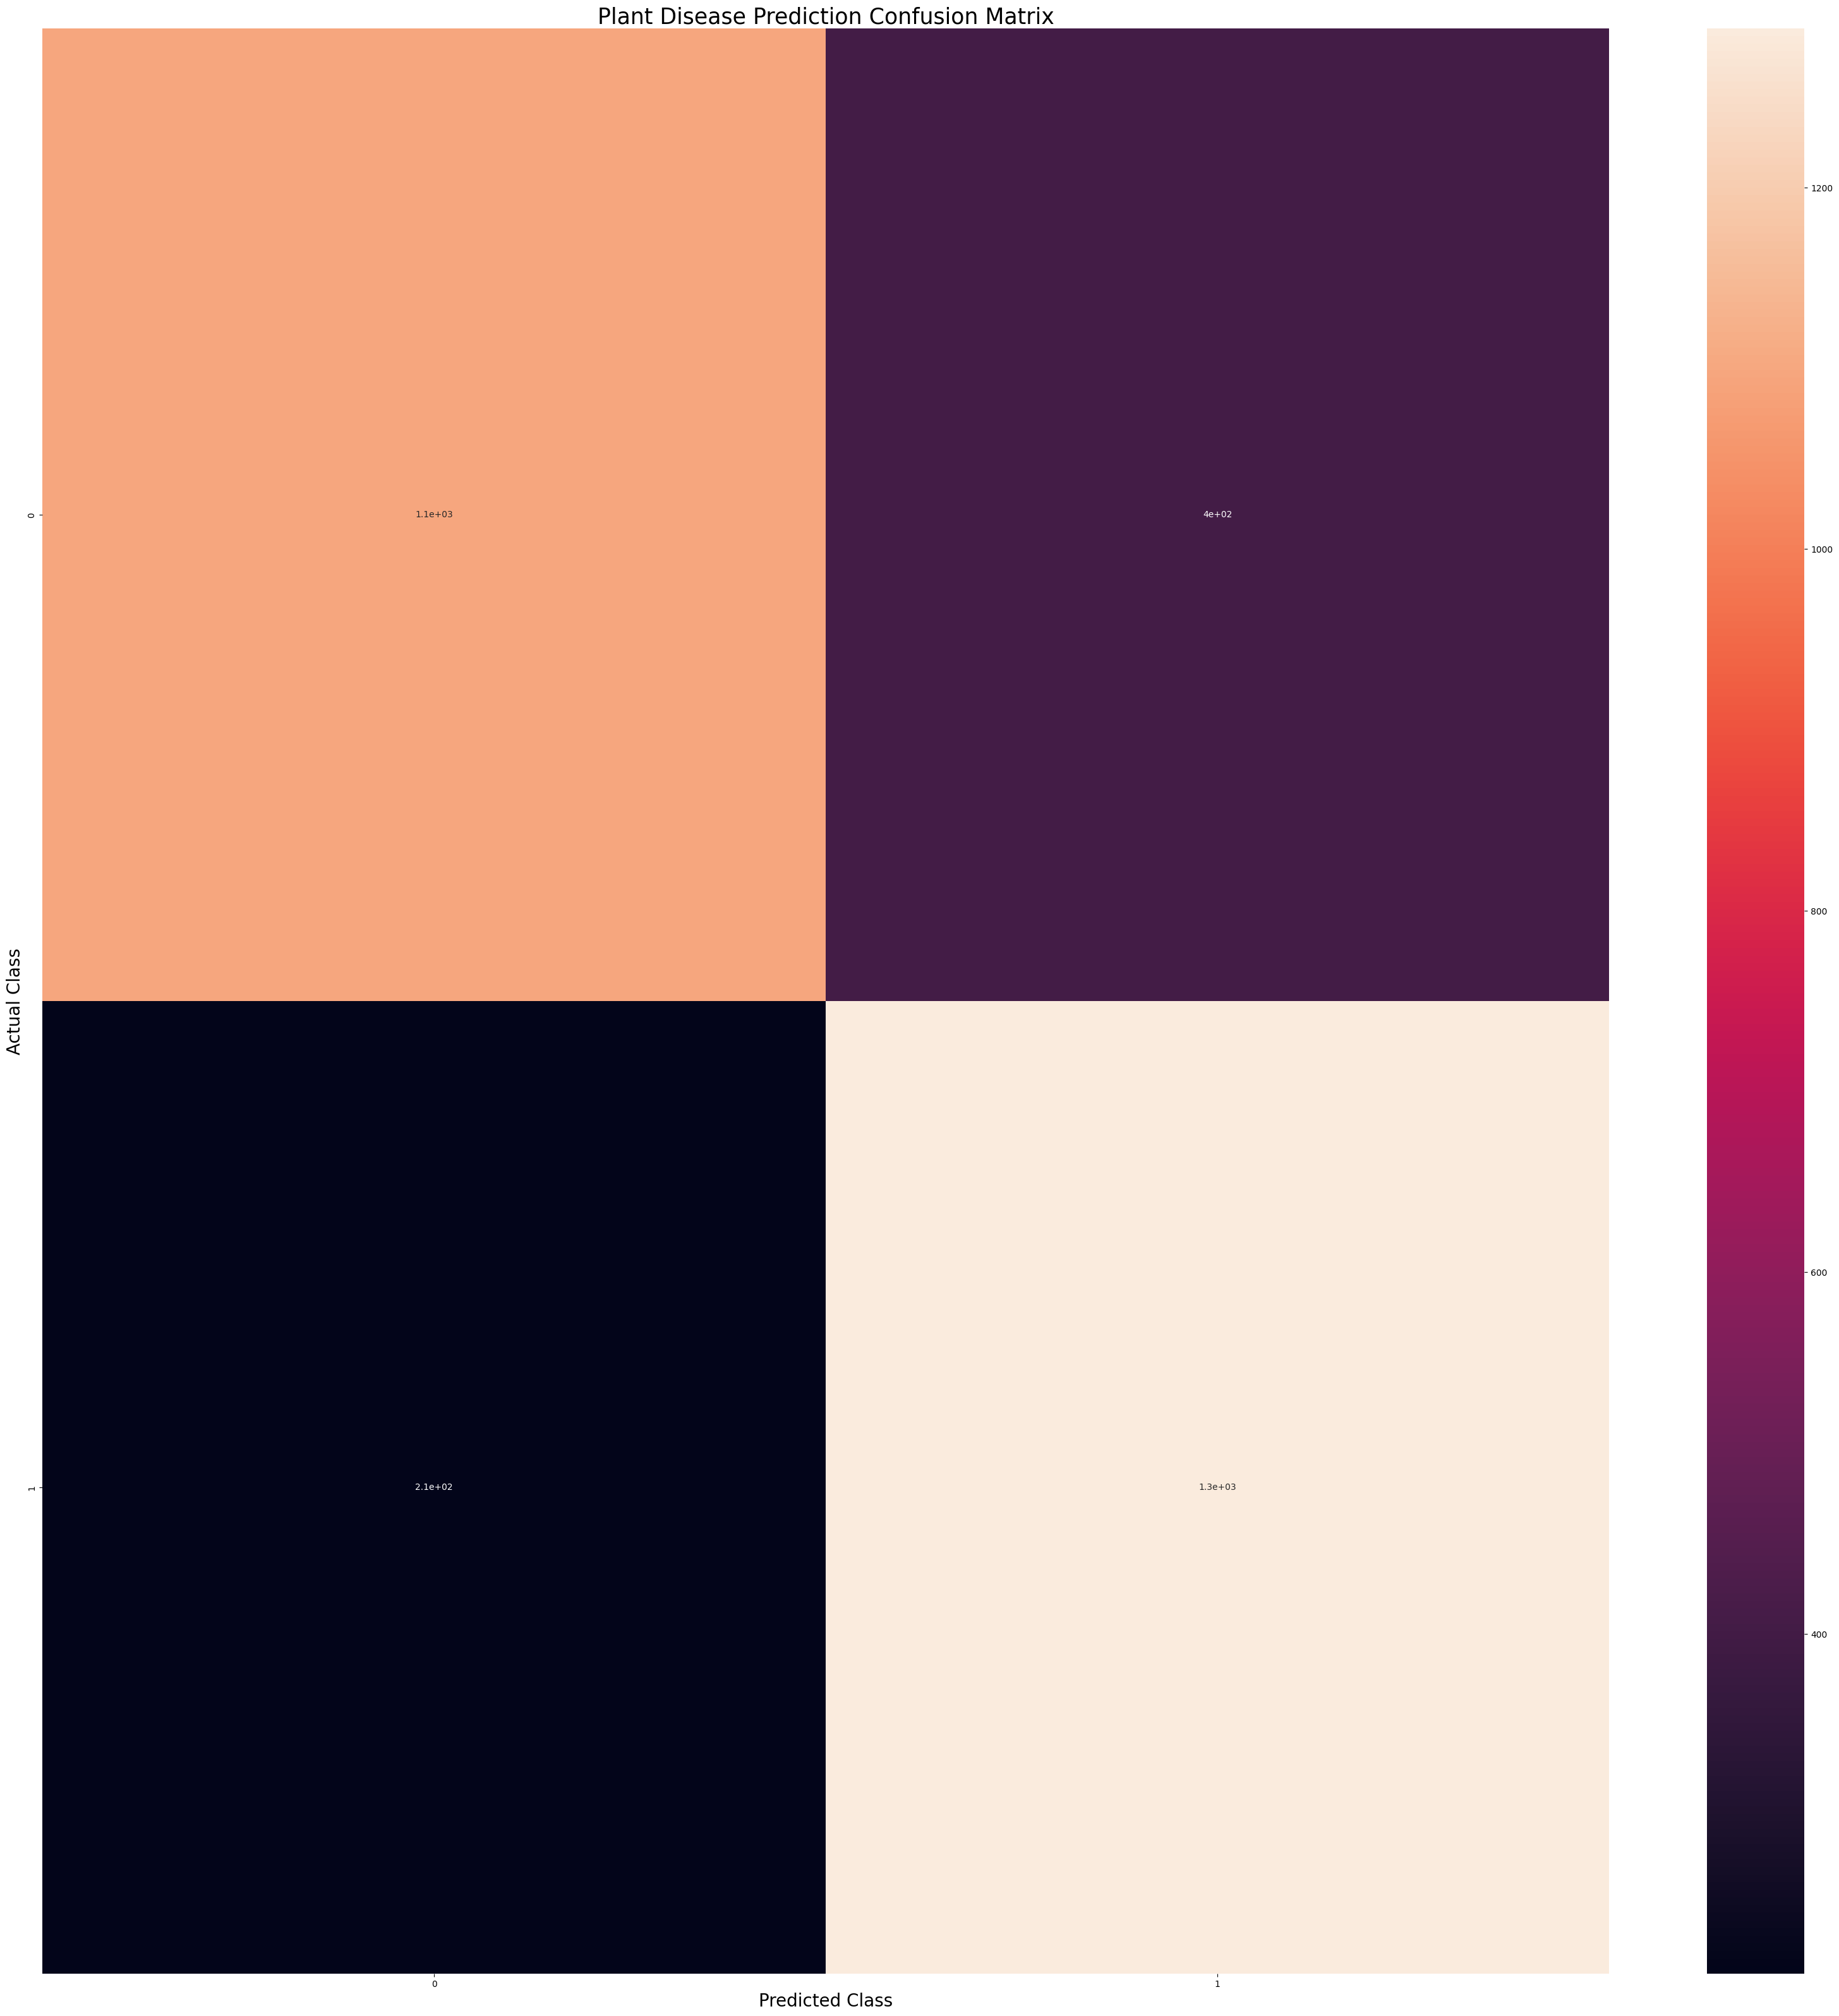

In [83]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()